Import the Required Libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Build a Sample Circuit

Original circuit:


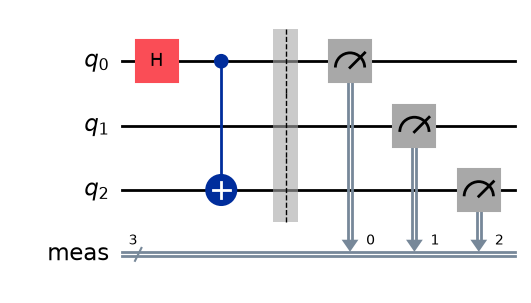

In [2]:
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 2)
qc.measure_all()

print("Original circuit:")
qc.draw('mpl')

Set Up the Simulator Backend with a Restricted Coupling Map

In [3]:
simulator = AerSimulator()

coupling_map = [[0, 1], [1, 0], [1, 2], [2, 1]]
basis_gates = ['u1', 'u2', 'u3', 'cx']

print("Custom coupling map (linear chain):")
print(coupling_map)

Custom coupling map (linear chain):
[[0, 1], [1, 0], [1, 2], [2, 1]]


Automatic Layout Selection

Transpiled circuit with automatic layout:


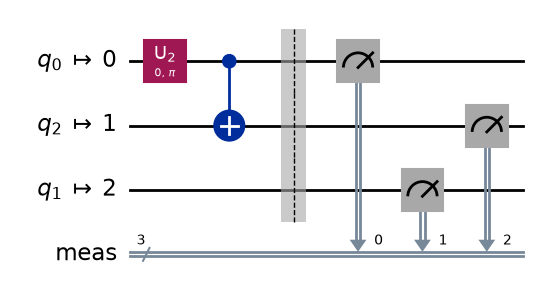

In [4]:
auto_transpiled = transpile(
    qc,
    basis_gates=basis_gates,
    coupling_map=coupling_map,
    optimization_level=1
)

print("Transpiled circuit with automatic layout:")
auto_transpiled.draw('mpl')

Manual Layout Selection

Transpiled circuit with manual layout (initial_layout=[0, 1, 2]):


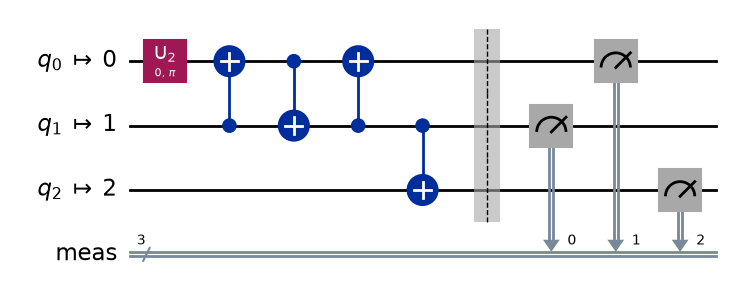

In [5]:
manual_transpiled = transpile(
    qc,
    basis_gates=basis_gates,
    coupling_map=coupling_map,
    initial_layout=[0, 1, 2],
    optimization_level=1
)

print("Transpiled circuit with manual layout (initial_layout=[0, 1, 2]):")
manual_transpiled.draw('mpl')

Comparing the Results

In [6]:
print("Automatic layout - Depth:", auto_transpiled.depth())
print("Automatic layout - Gate counts:", auto_transpiled.count_ops())

print("Manual layout - Depth:", manual_transpiled.depth())
print("Manual layout - Gate counts:", manual_transpiled.count_ops())

Automatic layout - Depth: 3
Automatic layout - Gate counts: OrderedDict({'measure': 3, 'u2': 1, 'cx': 1, 'barrier': 1})
Manual layout - Depth: 6
Manual layout - Gate counts: OrderedDict({'cx': 4, 'measure': 3, 'u2': 1, 'barrier': 1})
